# Datos

```{admonition} Alcance
:class: tip
Este capítulo describe el panel completo. Desde el capítulo 2 se trabaja solo con el conjunto de
entrenamiento.
```

## Fuente

Los datos provienen del sistema de nómina SAP de un grupo empresarial colombiano dedicado
principalmente a la producción y comercialización de oleaginosas. De allí se toman la foto mensual
de cada colaborador (sociedad, subdivisión, cargo, función, departamento, contrato y datos
demográficos), los retiros con su tipo y la historia de contratos con sus fechas de vigencia. El
tipo de personal (administrativo, operativo directo, operativo indirecto) se deriva del centro de
costo con la regla contable de la empresa.

Los datos son propiedad de la empresa, que autorizó su uso académico; no tienen licencia pública y
no se publican. La cédula nunca se exporta: se reemplaza por un identificador aleatorio antes de
construir el panel.

Elegimos este conjunto de datos porque la rotación voluntaria tiene un costo directo para la
empresa (selección, inducción, curva de aprendizaje) y se concentra en las operaciones de campo y
planta. Además, plantea varias dificultades propias del curso: un evento raro (1 %), un panel con
entidades repetidas, una dimensión temporal, fugas de información en la fuente y variables
categóricas de alta cardinalidad. Con 85.223 observaciones supera el mínimo de 20.000.

## Construcción del panel

- **Unidad:** persona × mes. La persona se identifica por cédula y no por número de personal, porque
  1.904 personas tienen más de uno.
- **Episodios laborales:** una ausencia de al menos un mes abre un episodio nuevo y reinicia la
  antigüedad. Un traslado entre sociedades sin pausa no la reinicia (se verificó en las 3.902
  transiciones).
- **Objetivo:** `y_renuncia = 1` en el último mes de un episodio que termina por renuncia
  voluntaria. Las otras salidas (despido, fin de contrato, pensión, fallecimiento) valen 0 en su
  último mes, y después la persona sale del panel: estuvo en riesgo y no renunció (riesgos
  competitivos).
- **Renuncia administrativa:** renuncia registrada en SAP tras la cual la persona sigue al mes
  siguiente con otro número de personal. No se cuenta como salida (`y = 0`).
- **Exclusiones:** aprendices (por contrato, función o cargo), vicepresidencia y presidencia (7
  personas, identificables), contratos de obra o labor, y el mes de salida de los casos con etiqueta
  dudosa (salida sin registro en SAP, terminación en periodo de prueba).
- **Momento de medición:** todas las covariables corresponden al día 1 del mes *t*. El cargo entra
  con un mes de rezago (`cargo_t1`) porque SAP lo vacía en el mes de salida (capítulo 6). El
  contrato es el vigente en ese mes según la historia de contratos, y no el del reporte mensual,
  que copia el contrato actual a todos los meses anteriores.
- **Puesto:** cinco campos de SAP con cientos de textos (495 cargos) se descomponen en ejes sin
  repetición: `nivel` (de la función), `familia_cargo` y `oficio` (del cargo), `tipo_unidad` y
  `area_funcional` (del departamento) y `proceso_planta` (del nombre del centro de costo).

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
from comun import (cargar, estilo, tasa, OBJETIVO, NUM, BIN, CAT, PREDICTORAS, TRAZA, SEMILLA,
                   VERDE, BORDE)

estilo()
pd.set_option('display.width', 140)

p = cargar()
n_ren = p[OBJETIVO].sum()
n_no = (p[OBJETIVO] == 0).sum()
print(f'filas: {len(p):,} | personas: {p.persona_id.nunique():,} | meses: {p.mes.nunique()} '
      f'({p.mes.min()} a {p.mes.max()}) | columnas: {p.shape[1]}')
print(f'predictoras: {len(PREDICTORAS)} | renuncias: {n_ren} | '
      f'prevalencia: {100 * p[OBJETIVO].mean():.2f} %')
print(f'filas por variable: {len(p) / len(PREDICTORAS):,.0f} '
      f'(por columna tras codificar las 183: {len(p) / 183:,.0f})')
print(f'clase positiva: {n_ren} renuncias frente a {n_no:,} no renuncias (1 a {n_no / n_ren:.0f})')

filas: 85,223 | personas: 5,747 | meses: 20 (2025-01 a 2026-08) | columnas: 27
predictoras: 18 | renuncias: 892 | prevalencia: 1.05 %
filas por variable: 4,735 (por columna tras codificar las 183: 466)
clase positiva: 892 renuncias frente a 84,331 no renuncias (1 a 95)


Hay 5.747 personas distintas. El tamaño efectivo de la muestra está entre ese número y el de filas,
porque los meses de una misma persona están correlacionados (sección 1.7).

### Por qué una fila por persona y mes

El panel persona-mes es la forma habitual de un modelo de riesgo en tiempo discreto (Allison, 1982;
Singer y Willett, 2003). Para la persona *i* en el mes *t*, el riesgo es la probabilidad de renunciar
en ese mes dado que sigue activa al inicio:

$$
h_{it} = P(y_{it} = 1 \mid \text{activa al inicio de } t,\ x_{it}),
\qquad \operatorname{logit} h_{it} = x_{it}^\top \beta .
$$

La verosimilitud del panel es

$$
L(\beta) = \prod_{i} \prod_{t \in R_i} h_{it}^{\,y_{it}} \, (1 - h_{it})^{1 - y_{it}},
$$

donde $R_i$ son los meses en que la persona *i* estuvo en riesgo. Es la misma verosimilitud de un
modelo de supervivencia con censura: quien sigue activa al final de la ventana aporta sus meses sin
renuncia, y quien sale por otra causa deja de aportar desde su salida. Como cada persona tiene a lo
sumo una renuncia, el producto sobre sus meses es la probabilidad de su historia completa, y que una
persona aporte varias filas no sesga la estimación. Sí puede hacer optimistas los intervalos que
tratan las filas como independientes, si hay diferencias entre personas que las variables no
recogen (sección 1.7). La probabilidad de seguir activa *k* meses es
$S_{ik} = \prod_{t=1}^{k} (1 - h_{it})$ (sección 7.10).

Se prefiere a una fila por persona, con la etiqueta "renunció o no", por cuatro razones:

1. **Tiempo de exposición.** Las personas se observan entre 1 y 20 meses. Con una fila por persona,
   quien estuvo 3 meses tuvo menos oportunidad de renunciar que quien estuvo 20, y la etiqueta mezcla
   el riesgo con el tiempo de observación. Con una tasa de 1 % mensual, la probabilidad de renunciar
   en 3 meses es 1 − 0,99³ ≈ 3 % y en 16 meses 1 − 0,99¹⁶ ≈ 15 %, sin que el riesgo cambie. En el
   panel cada fila vale un mes.
2. **Variables que cambian.** Edad, antigüedad, contrato, cargo y sociedad cambian de un mes a otro.
   Una fila por persona obliga a elegir un momento y descarta el resto.
3. **Un reloj común.** Si los activos se describen en el último mes y los que renunciaron en su mes
   de salida, las dos poblaciones se miden en momentos distintos, y quien se fue no pudo seguir
   acumulando antigüedad: "los que renuncian tienen menos antigüedad" quedaría construido por el
   diseño. En el panel todas las variables se miden el día 1 del mes, antes de conocer el desenlace.
   Por la misma razón no se usa como variable el número total de meses que duró cada persona, que
   solo se conoce cuando termina el episodio.
4. **El corte transversal es un caso particular.** La versión válida de una fila por persona toma a
   las activas en una fecha y define *y* como la renuncia en los *k* meses siguientes. Usa las
   variables de un solo mes y una ventana elegida a mano, y la foto del último mes no sirve para
   entrenar porque su desenlace todavía no ocurrió. El panel usa todos los meses y da el riesgo de
   cualquier mes con un solo modelo.

## Diccionario

Las columnas de trazabilidad (`funcion`, `cargo_t1`, `departamento`, `area`) contienen los textos
originales de SAP de los que salen los ejes de puesto; no entran al modelo y no se muestran.
`evento` y `tipo_retiro` describen la salida y tampoco son predictoras.

In [2]:
DESC = {
    'persona_id': 'persona seudonimizada (agrupa filas)',
    'mes': 'mes t (AAAA-MM)',
    'sociedad': 'empresa de nómina, S01..S22 por tamaño',
    'linea': 'línea de negocio de la sociedad',
    'ubicacion': 'subdivisión de personal (finca o planta), codificada',
    'edad': 'años al día 1 del mes',
    'antig_meses': 'meses desde el ingreso; se reinicia con cada reingreso',
    'genero': 'género',
    'estado_civil': 'unión libre, soltero, casado, otro',
    'contrato': 'contrato vigente en el mes (historia de contratos)',
    'nivel': 'nivel jerárquico, desde la función',
    'familia_cargo': 'tipo de trabajo, desde el cargo t-1',
    'oficio': 'cargo t-1 sin palabras de nivel; en campo, la labor',
    'tipo_unidad': 'finca de palma o banano, hacienda, planta u oficina',
    'area_funcional': 'área de oficina; no_aplica en fincas y plantas',
    'proceso_planta': 'estación de planta, desde el centro de costo; no_aplica fuera de planta',
    'tipo_costos': 'administrativo, operativo directo, operativo indirecto',
    'primer_mes': '1 en el primer mes de un episodio (no hay cargo previo)',
    'reingreso': '1 si tuvo un episodio anterior desde 2010',
    'traslado_12m': '1 si cambió de sociedad sin pausa en los 12 meses previos',
    'evento': 'ninguno, renuncia, otra_salida, renuncia_administrativa',
    'tipo_retiro': 'tipo SAP de las otras salidas',
    'y_renuncia': 'variable objetivo',
}
UNIDAD_DIC = {'edad': 'años', 'antig_meses': 'meses', 'mes': 'mes calendario',
              'persona_id': 'entero sin orden', **{c: '0/1' for c in BIN + [OBJETIVO]}}
ROL = {**{c: 'numérica' for c in NUM}, **{c: 'binaria' for c in BIN},
       **{c: 'categórica' for c in CAT},
       'persona_id': 'id', 'mes': 'tiempo', 'evento': 'desenlace', 'tipo_retiro': 'desenlace',
       OBJETIVO: 'objetivo'}

cols = [c for c in p.columns if c not in TRAZA]
dic = pd.DataFrame({
    'rol': [ROL[c] for c in cols],
    'tipo': [str(p[c].dtype) for c in cols],
    'unidad': [UNIDAD_DIC.get(c, 'categoría') for c in cols],
    'distintos': [p[c].nunique() for c in cols],
    'nulos': [int(p[c].isna().sum()) for c in cols],
    '% nulos': [round(100 * p[c].isna().mean(), 2) for c in cols],
    'descripción': [DESC[c] for c in cols],
}, index=cols)
dic

,rol,tipo,unidad,distintos,nulos,% nulos,descripción
persona_id,id,int64,entero sin orden,5747,0,0.00,persona seudonimizada (agrupa filas)
mes,tiempo,object,mes calendario,20,0,0.00,mes t (AAAA-MM)
sociedad,categórica,object,categoría,22,0,0.00,"empresa de nómina, S01..S22 por tamaño"
linea,categórica,object,categoría,6,0,0.00,línea de negocio de la sociedad
ubicacion,categórica,object,categoría,57,0,0.00,"subdivisión de personal (finca o planta), codi..."
edad,numérica,float64,años,61,1,0.00,años al día 1 del mes
antig_meses,numérica,int64,meses,200,0,0.00,meses desde el ingreso; se reinicia con cada r...
genero,categórica,object,categoría,2,0,0.00,género
estado_civil,categórica,object,categoría,4,20,0.02,"unión libre, soltero, casado, otro"
contrato,categórica,object,categoría,2,0,0.00,contrato vigente en el mes (historia de contra...


## Faltantes

Los nulos son estructurales y la base no los imputa; su tratamiento queda en el `Pipeline`
(capítulo 7).

- `familia_cargo` y `oficio`: primer mes de un episodio, cuando no hay cargo del mes previo. La
  variable `primer_mes` registra ese hecho.
- `tipo_retiro`: solo existe cuando hubo otra salida.
- `nivel`, `estado_civil` y `edad`: pocas filas con el campo vacío en SAP (una edad imposible se
  pasó a nulo).

In [3]:
nulos = p[PREDICTORAS].isna().sum()
nulos = nulos[nulos > 0]
fam_nulo = p.familia_cargo.isna()
print('nulos en predictoras:', nulos.to_dict())
print(f'familia_cargo nula y primer_mes = 1: '
      f'{int((fam_nulo & (p.primer_mes == 1)).sum())} de {int(fam_nulo.sum())}')
tasa(p, fam_nulo.map({True: 'familia nula', False: 'familia conocida'})).round(2)

nulos en predictoras: {'edad': 1, 'estado_civil': 20, 'nivel': 14, 'familia_cargo': 1954, 'oficio': 1954}
familia_cargo nula y primer_mes = 1: 1875 de 1954


familia_cargo,filas,renuncias,tasa_%
familia conocida,83269,861,1.03
familia nula,1954,31,1.59


En la matriz de nulos cada columna es una persona-mes (muestra de 3.000, ordenada por mes) y cada
fila, una variable con algún nulo.

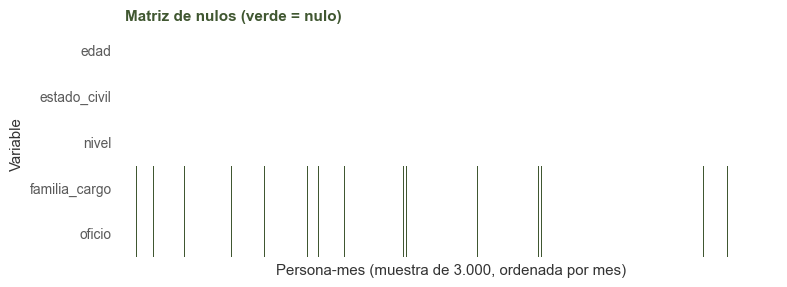

filas con al menos un nulo en predictoras: 1987
nulos simultáneos en familia y oficio: 1954


In [4]:
con_nulos = [c for c in PREDICTORAS if p[c].isna().any()]
muestra = p.sample(3000, random_state=SEMILLA).sort_values('mes')

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(muestra[con_nulos].isna().T, cbar=False, cmap=['#FFFFFF', VERDE], ax=ax,
            xticklabels=False)
ax.set(title='Matriz de nulos (verde = nulo)',
       xlabel='Persona-mes (muestra de 3.000, ordenada por mes)', ylabel='Variable')
plt.tight_layout()
plt.show()

print('filas con al menos un nulo en predictoras:', int(p[con_nulos].isna().any(axis=1).sum()))
ambos = int((p.familia_cargo.isna() & p.oficio.isna()).sum())
print('nulos simultáneos en familia y oficio:', ambos)

Para el mecanismo de los faltantes, la prueba de Little no aplica, porque supone variables
continuas y casi todas las nuestras son categóricas. En su lugar comparamos las filas completas con
las incompletas.

In [5]:
cols_comp = ['edad', 'antig_meses', 'primer_mes', 'reingreso']
comp = pd.DataFrame({
    'familia nula': p[fam_nulo][cols_comp].mean(),
    'familia conocida': p[~fam_nulo][cols_comp].mean(),
}).round(2)
comp.loc['% término fijo'] = [
    round(100 * (p[fam_nulo].contrato == 'Termino Fijo').mean(), 1),
    round(100 * (p[~fam_nulo].contrato == 'Termino Fijo').mean(), 1),
]
comp

,familia nula,familia conocida
edad,29.48,37.57
antig_meses,0.92,60.57
primer_mes,0.96,0.00
reingreso,0.09,0.08
% término fijo,98.50,52.50


Las filas con familia nula son casi todas de antigüedad 0, más jóvenes (29 frente a 38 años) y casi
todas con contrato a término fijo (98 % frente a 52 %); la proporción de reingresos es la misma. El
nulo depende de variables observadas (`primer_mes`, `antig_meses`) y no del valor que falta, por lo
que es un faltante MAR estructural. No es MCAR, porque las distribuciones difieren, y no hay indicios
de MNAR. Las otras tres variables con nulos (`edad`, `estado_civil`, `nivel`) suman 35 filas de
85.223, sin patrón, y se tratan como MCAR.

En esas filas la tasa de renuncia es mayor. Imputar con la moda borraría esa diferencia; por eso el
`Pipeline` trata el nulo como una categoría propia.

## Duplicados, valores imposibles y atípicos

In [6]:
print('filas persona-mes duplicadas:', int(p.duplicated(['persona_id', 'mes']).sum()))

sin_id = p.drop(columns=['persona_id', 'mes'] + TRAZA + ['evento', 'tipo_retiro'], errors='ignore')
casi_dup = sin_id.duplicated(keep=False)
print(f'casi-duplicados (mismo vector de predictoras y objetivo): '
      f'{int(casi_dup.sum()):,} filas ({100 * casi_dup.mean():.0f} %)')

edad_ingreso = p.edad - p.antig_meses / 12
print(f'edad: {p.edad.min():.0f} a {p.edad.max():.0f} años | mayores de 70: '
      f'{int((p.edad > 70).sum())} filas ({p[p.edad > 70].persona_id.nunique()} personas)')
print(f'antigüedad: {p.antig_meses.min()} a {p.antig_meses.max()} meses | '
      f'negativa: {int((p.antig_meses < 0).sum())}')
print(f'ingreso antes de los 15 años: {int((edad_ingreso < 15).sum())} filas | '
      f'antes de los 18: {int((edad_ingreso < 18).sum())}')

# atípicos por la regla de 1,5 x IQR
for v in NUM:
    q1, q3 = p[v].quantile([0.25, 0.75])
    li, ls = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    fuera = int(((p[v] < li) | (p[v] > ls)).sum())
    print(f'{v}: IQR [{q1:.0f}, {q3:.0f}], vallas [{li:.0f}, {ls:.0f}], fuera: {fuera} filas')

filas persona-mes duplicadas: 0


casi-duplicados (mismo vector de predictoras y objetivo): 16,716 filas (20 %)
edad: 18 a 80 años | mayores de 70: 102 filas (8 personas)
antigüedad: 0 a 199 meses | negativa: 0
ingreso antes de los 15 años: 0 filas | antes de los 18: 516
edad: IQR [28, 45], vallas [2, 70], fuera: 102 filas
antig_meses: IQR [13, 93], vallas [-107, 213], fuera: 0 filas


- No hay filas persona-mes repetidas.
- Una de cada cinco filas comparte todo el vector de variables con otra. Son personas distintas con
  el mismo perfil (sociedad, oficio, contrato, edad y antigüedad), algo esperable en un panel de
  operarios; no puede tratarse de la misma persona, porque su antigüedad cambia cada mes. No se
  eliminan, ya que cada fila es una persona en riesgo ese mes.
- La única edad imposible (2 años) se pasó a nulo al construir el panel. No hay antigüedades
  negativas ni ingresos antes de los 15 años. Las 516 filas con ingreso entre los 15 y los 17 años
  son legales con permiso de trabajo y suelen corresponder a aprendices contratados; se conservan.
- Con la regla de 1,5 × IQR la antigüedad no tiene atípicos (su rango intercuartílico es amplio) y
  la edad tiene 102 filas por encima de 70 años, de 8 personas. Son valores reales y no se recortan:
  la logística los recibe estandarizados, y la antigüedad entra además en logaritmo.
- Los cargos y departamentos mal escritos (textos truncados por SAP a 25 caracteres, abreviaturas
  como COORD o MTTO, tildes y espacios) se unificaron al construir el panel: los 495 cargos
  originales quedan en 41 oficios.

## Sesgos de muestreo y representatividad

- **Cobertura:** 22 sociedades, elegidas por su tamaño y por tener datos completos en la ventana. El
  modelo describe las operaciones grandes (palma, banano, industria, transporte, puerto, ganadería)
  y no a todo el grupo.
- **Solo nómina directa:** quien trabaja por contratista o como temporal no está en SAP. En campo
  esa población puede ser grande y rotar de otra manera.
- **Exclusiones:** aprendices (1.822 persona-mes, con rotación reglada por su contrato),
  vicepresidencia y presidencia (122), obra o labor (17) y 123 meses de salida con etiqueta dudosa.
  Las conclusiones no se extienden a esos grupos.
- **Ventana:** 20 meses. Los efectos de calendario se observan a lo sumo dos veces.
- **Sociedad de nómina y lugar de trabajo:** parte del personal indirecto trabaja para otra sociedad
  del grupo, y ningún campo lo registra.
- **Supervivencia:** quien lleva 10 años llegó ahí porque no renunció antes. La tasa baja de las
  antigüedades altas mezcla el efecto del tiempo con la selección de quienes permanecen.

## Entidades y dependencia

Las filas no son independientes: la misma persona aparece hasta 20 veces. Una partición aleatoria
por filas dejaría meses de una misma persona en entrenamiento y en validación, y el modelo se
evaluaría sobre personas que ya vio. Por eso el test es un corte en el tiempo, la validación
principal del capítulo 7 es temporal y, como complemento, se usa una validación agrupada por
`persona_id`.

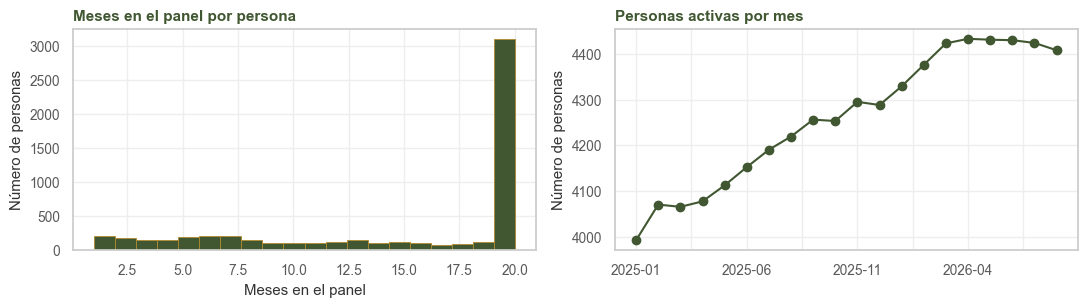

meses por persona: mediana 20, media 14.8; personas con los 20 meses: 3,101 (54 %)
personas con al menos una renuncia: 889


In [7]:
meses_persona = p.groupby('persona_id').size()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(meses_persona, bins=20, color=VERDE, **BORDE)
ax[0].set(title='Meses en el panel por persona', xlabel='Meses en el panel',
          ylabel='Número de personas')
p.groupby('mes').size().plot(ax=ax[1], marker='o', color=VERDE)
ax[1].set(title='Personas activas por mes', xlabel='', ylabel='Número de personas')
plt.tight_layout()
plt.show()

completas = int((meses_persona == 20).sum())
print(f'meses por persona: mediana {meses_persona.median():.0f}, media {meses_persona.mean():.1f}; '
      f'personas con los 20 meses: {completas:,} ({100 * completas / len(meses_persona):.0f} %)')
print(f'personas con al menos una renuncia: {p.groupby("persona_id")[OBJETIVO].max().sum():,}')

## Consideraciones éticas y reidentificación

El panel no tiene nombre, cédula, número de personal, fecha de nacimiento ni centro de costo. Aun
así no es anónimo: la combinación de empresa, edad, género, puesto y antigüedad describe a una
persona concreta. La tabla mide cuántas personas de un mes quedan en grupos de menos de cinco con
los cuasi-identificadores que un compañero de trabajo podría conocer.

In [8]:
m = p[p.mes == '2026-03'].copy()
m['edad_q'] = (m.edad // 5 * 5).astype('Int64')
m['antig_a'] = pd.cut(m.antig_meses, [-1, 11, 23, 59, 119, 1e4],
                      labels=['<1', '1', '2-4', '5-9', '10+'])
VARIANTES = {
    'tal como está': ['sociedad', 'ubicacion', 'genero', 'edad', 'antig_meses', 'nivel', 'oficio',
                      'proceso_planta', 'tipo_unidad', 'area_funcional'],
    'sin ubicación; edad y antigüedad agrupadas': ['sociedad', 'genero', 'edad_q', 'antig_a', 'nivel',
                                                   'oficio', 'proceso_planta', 'tipo_unidad',
                                                   'area_funcional'],
    'línea en vez de sociedad; familia en vez de oficio': ['linea', 'genero', 'edad_q', 'antig_a',
                                                           'nivel', 'familia_cargo', 'tipo_unidad',
                                                           'area_funcional'],
    'lo anterior sin nivel': ['linea', 'genero', 'edad_q', 'antig_a', 'familia_cargo',
                              'tipo_unidad', 'area_funcional'],
}
filas = []
for nombre, cuasi in VARIANTES.items():
    k = m.groupby(cuasi, dropna=False, observed=True).size()
    filas.append((nombre, int((k == 1).sum()), round(100 * k[k < 5].sum() / k.sum())))
k_anonimato = pd.DataFrame(filas, columns=['variante', 'personas únicas (k=1)', '% en grupos k<5'])
k_anonimato.set_index('variante')

variante,personas únicas (k=1),% en grupos k<5
tal como está,3770,96
sin ubicación; edad y antigüedad agrupadas,1565,58
línea en vez de sociedad; familia en vez de oficio,1010,41
lo anterior sin nivel,765,35


Aun con todas las variables agrupadas, más de un tercio de las personas queda en grupos de menos de
cinco en un solo mes, y la trayectoria de 20 meses identifica todavía a más. Llegar a un nivel
seguro exigiría quitar lo que el modelo necesita, y por ello decidimos no publicar el panel. El libro
muestra código, tablas agregadas y métricas, sin filas individuales ni textos originales de SAP.

Hay además dos riesgos en el uso del modelo. Un puntaje de riesgo de renuncia puede servir para
retener o para no renovar contratos; el segundo uso perjudica a quien el modelo señala, y como el
término fijo es una de las variables con más señal, podría volverse un motivo más para no pasar a
nadie a indefinido. El género no tiene señal propia (capítulo 6), pero se reparte de forma muy
desigual entre familias de cargo, de modo que un modelo que no lo usa puede aprenderlo a través de
la familia.